In [2]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms

In [3]:
#load data
MASK_PATH = "/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif"
clim = xr.open_dataset('../outputs/combined_monthly_day_2008_2020_coarse.nc')

In [4]:
clim

<xarray.Dataset> Size: 2MB
Dimensions:      (lat: 20, lon: 180, time: 156)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01
Data variables:
    LST          (lat, lon, time) float32 2MB ...

In [5]:
climatology = clim.groupby("time.season").mean("time")

In [6]:
print("Loading water mask...")
clouds = xr.open_dataset('../data/ice_flc_percent_2008_2020_2deg.nc')
example = clouds['ice_flc_percent'].isel(year=1, month=1)

water_mask = rioxarray.open_rasterio(MASK_PATH).squeeze()

water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))
water_interp = water_mask.interp(lat=clim.coords['lat'], lon=clim.coords['lon'], method='nearest')

water_mask_true = clim['LST'].isel(time=0).copy(data=np.array(np.squeeze(water_interp)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)

# Apply mask
clim_masked = climatology['LST'] * ls_mask


Loading water mask...


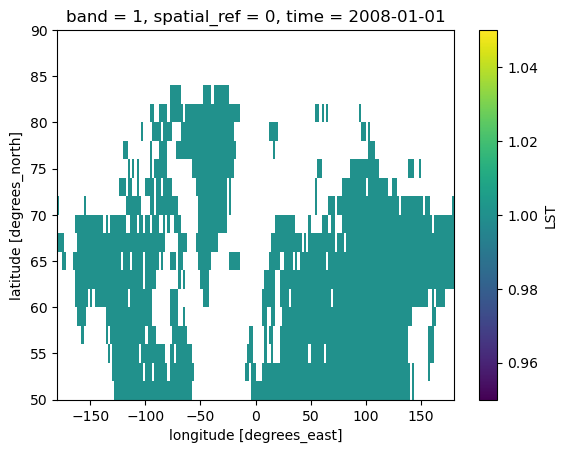

In [7]:
ls_mask.plot()

In [8]:
clim_masked

<xarray.DataArray 'LST' (season: 4, lat: 20, lon: 180)> Size: 58kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
    time         datetime64[ns] 8B 2008-01-01

/tmp/ipykernel_72918/1047835957.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


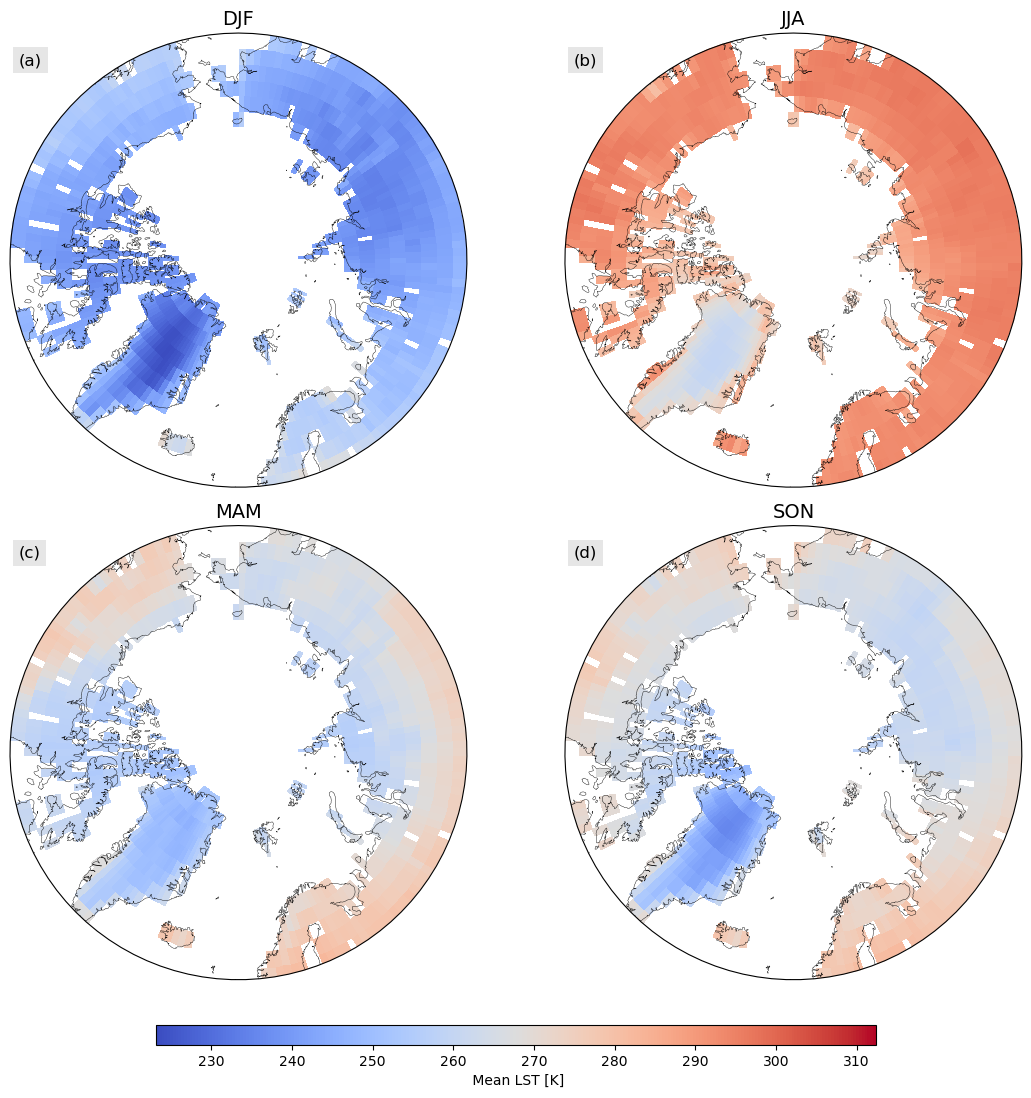

In [32]:
vmin = float(clim_masked.min())
vmax = float(clim_masked.max())

proj = ccrs.NorthPolarStereo()

# --- get seasons dynamically (important!) ---
seasons = list(clim_masked['season'].values)

# --- create mosaic layout (assumes 4 seasons) ---
fig, axs = plt.subplot_mosaic(
    [['(a)', '(b)'], ['(c)', '(d)']],
    figsize=(12, 10),
    subplot_kw=dict(projection=proj)
)

labels = ['(a)', '(b)', '(c)', '(d)']

# --- circular boundary ---
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# --- plotting loop ---
mappable = None

for i, (season, lab) in enumerate(zip(seasons, labels)):
    ax = axs[lab]

    da = clim_masked.sel(season=season)

    mappable = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- map styling ---
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.3)

    ax.set_title(str(season), fontsize=14)

# --- panel labels ---
for lab, ax in axs.items():
    trans = mtransforms.ScaledTranslation(-10/72, 2/72, fig.dpi_scale_trans)
    ax.text(
        0.05, 0.95, lab,
        transform=ax.transAxes + trans,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor='0.9', edgecolor='none')
    )

# --- make space at bottom ---
fig.subplots_adjust(bottom=0.12)

# --- add colorbar axis manually ---
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label(' Mean LST [K]')

plt.tight_layout()
plt.savefig('meanstate_arctic_day_coarse.png', dpi=300)

In [3]:
# Night time data
clim_night = xr.open_dataset('../outputs/combined_monthly_NIGHT_2008_2020_coarse.nc')

In [12]:
clim_night

<xarray.Dataset> Size: 2MB
Dimensions:      (lat: 20, lon: 180, time: 156)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01
Data variables:
    LST          (lat, lon, time) float32 2MB ...

In [22]:
climatology_night = clim_night.groupby("time.season").mean("time")

In [23]:
# Apply mask
clim_masked_night = climatology_night['LST'] * ls_mask


In [24]:
clim_masked_night

<xarray.DataArray 'LST' (season: 4, lat: 20, lon: 180)> Size: 58kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
    time         datetime64[ns] 8B 2008-01-01

/tmp/ipykernel_72918/2282742182.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


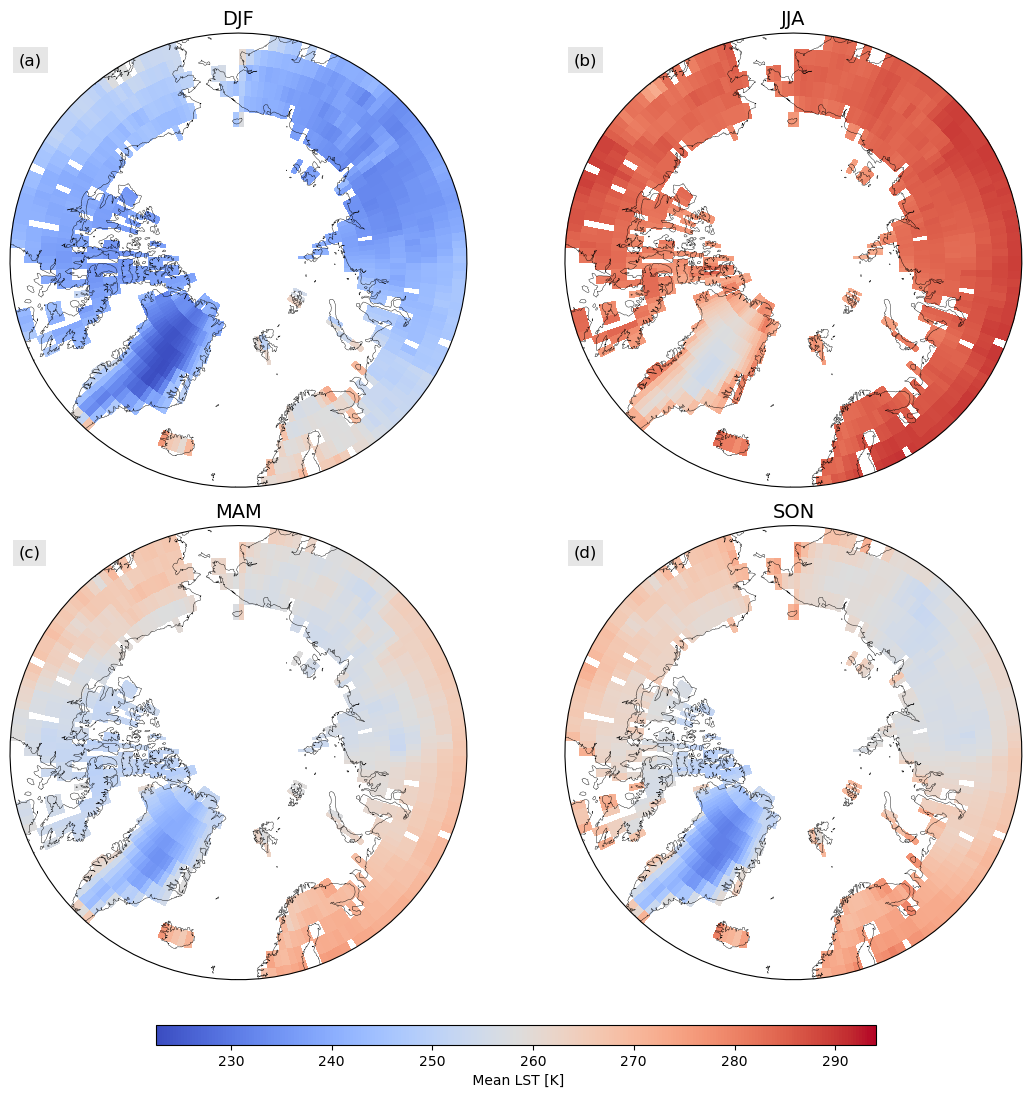

In [25]:
vmin = float(clim_masked_night.min())
vmax = float(clim_masked_night.max())

proj = ccrs.NorthPolarStereo()

# --- get seasons dynamically (important!) ---
seasons = list(clim_masked_night['season'].values)

# --- create mosaic layout (assumes 4 seasons) ---
fig, axs = plt.subplot_mosaic(
    [['(a)', '(b)'], ['(c)', '(d)']],
    figsize=(12, 10),
    subplot_kw=dict(projection=proj)
)

labels = ['(a)', '(b)', '(c)', '(d)']

# --- circular boundary ---
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# --- plotting loop ---
mappable = None

for i, (season, lab) in enumerate(zip(seasons, labels)):
    ax = axs[lab]

    da = clim_masked_night.sel(season=season)

    mappable = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- map styling ---
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.3)

    ax.set_title(str(season), fontsize=14)

# --- panel labels ---
for lab, ax in axs.items():
    trans = mtransforms.ScaledTranslation(-10/72, 2/72, fig.dpi_scale_trans)
    ax.text(
        0.05, 0.95, lab,
        transform=ax.transAxes + trans,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor='0.9', edgecolor='none')
    )

# --- make space at bottom ---
fig.subplots_adjust(bottom=0.12)

# --- add colorbar axis manually ---
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label(' Mean LST [K]')

plt.tight_layout()
plt.savefig('meanstate_arctic_night_coarse.png', dpi=300)